Ajustes nos parâmetros em dataset intermediário - Proteina 8IXO - (https://www.rcsb.org/structure/8IXO)

In [1]:
!pip install biopython pandas networkx numpy matplotlib seaborn infomap scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from Bio.PDB import PDBParser
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial import cKDTree
from matplotlib.patches import Patch
from networkx.algorithms.community import louvain_communities, modularity
from infomap import Infomap

Um arquivo PDB possui:
Estrutura
 └── Modelo
      └── Cadeia
           └── Resíduo
                └── Átomo

In [3]:
arquivo_pdb = "data/raw/1A3N/1A3N.pdb"
nome_proteina = arquivo_pdb.split("/")[-1].split(".")[0]
parser = PDBParser(QUIET=True)
estrutura = parser.get_structure(nome_proteina, arquivo_pdb)
print("Proteína carregada com sucesso!")

for modelo in estrutura:
    for cadeia in modelo:
        residuos = list(cadeia.get_residues())
        print("Número de resíduos:", len(residuos))

Proteína carregada com sucesso!
Número de resíduos: 265
Número de resíduos: 259
Número de resíduos: 242
Número de resíduos: 261


In [4]:
dados_residuos = []
for modelo in estrutura:
    for cadeia in modelo:
        for residuo in cadeia:
            if residuo.id[0] != " ":
                continue
            if "CA" not in residuo:
                print(f"Residuo {residuo.id} da cadeia {cadeia.id} não possui átomo CA. Pulando...")
                continue
            ca = residuo["CA"]
            x, y, z = ca.coord
            dados_residuos.append({
                "cadeia": cadeia.id,
                "residuo_id": residuo.id[1],
                "residuo_nome": residuo.resname,
                "x": x,
                "y": y,
                "z": z
            })
df_residuos = pd.DataFrame(dados_residuos)
df_residuos["node_id"] = (
    df_residuos["cadeia"].astype(str)
    + "_"
    + df_residuos["residuo_id"].astype(str)
)
print(df_residuos["node_id"].nunique())
print(len(df_residuos))
print(
    "Resíduos únicos:",
    df_residuos["residuo_id"].nunique()
)

print(
    "Node IDs únicos:",
    df_residuos["node_id"].nunique()
)

572
572
Resíduos únicos: 146
Node IDs únicos: 572


In [5]:
def construir_grafo_kdtree(df_residuos,limiar,mesma_cadeia=False):
    G = nx.Graph()
    # ------------------------
    # Adiciona nós
    # ------------------------
    for _, linha in df_residuos.iterrows():
        G.add_node(
            linha["node_id"],
            cadeia=linha["cadeia"],
            residuo=linha["residuo_nome"],
            residuo_id=linha["residuo_id"],
            x=linha["x"],
            y=linha["y"],
            z=linha["z"]
        )
    # ------------------------
    # KDTree
    # ------------------------
    coords = df_residuos[["x","y","z"]].values
    tree = cKDTree(coords)
    pares = tree.query_pairs(r=limiar)
    # ------------------------
    # Arestas
    # ------------------------
    for i, j in pares:
        r1 = df_residuos.iloc[i]
        r2 = df_residuos.iloc[j]
        if mesma_cadeia:
            if r1["cadeia"] != r2["cadeia"]:
                continue
        dist = np.linalg.norm(
            coords[i] - coords[j]
        )
        G.add_edge(
            r1["node_id"],
            r2["node_id"],
            # Mais próximo, maior o peso da aresta
            weight=1/dist
        )
    return G

In [6]:
def analisar_rede(G):
    resultado = {}
    resultado["nos"] = G.number_of_nodes()
    resultado["arestas"] = G.number_of_edges()
    resultado["densidade"] = nx.density(G)
    resultado["grau_medio"] = np.mean([d for _, d in G.degree()])
    resultado["clustering"] = (nx.average_clustering(G))
    resultado["componentes"] = (nx.number_connected_components(G))
    resultado["conectada"] = (nx.is_connected(G))
    return resultado

In [7]:
resultados_louvain = []
limiares = [6, 8, 10]

configuracoes = [
    ("Todas as Cadeias", False),
    ("Mesma Cadeia", True)
]

for modelo, mesma_cadeia in configuracoes:
    print(f"MODELO: {modelo}")

    for limiar in limiares:
        print(f"Executando Louvain para {limiar} Å")
        
        # Construir grafo
        G = construir_grafo_kdtree(
            df_residuos,
            limiar,
            mesma_cadeia=mesma_cadeia
        )

        # Comunidades Louvain
        comunidades = louvain_communities(G, seed=42)
        Q = modularity(G, comunidades)

        tamanhos = [len(c) for c in comunidades]

        # Analisar rede com a função auxiliar
        analise = analisar_rede(G)

        # Registrar resultados
        resultados_louvain.append({
            "modelo": modelo,
            "limiar": limiar,
            "comunidades": len(comunidades),
            "modularidade": Q,
            "maior_comunidade": max(tamanhos),
            "menor_comunidade": min(tamanhos),
            "media_comunidades": np.mean(tamanhos),
            **analise  # incorpora métricas da função analisar_rede
        })

        print(f"Comunidades: {len(comunidades)}")
        print(f"Modularidade: {Q:.4f}")
        print(f"Métricas da rede: {analise}")


MODELO: Todas as Cadeias
Executando Louvain para 6 Å
Comunidades: 16
Modularidade: 0.8604
Métricas da rede: {'nos': 572, 'arestas': 1765, 'densidade': 0.01080793112316755, 'grau_medio': np.float64(6.171328671328672), 'clustering': 0.5654415029415027, 'componentes': 1, 'conectada': True}
Executando Louvain para 8 Å
Comunidades: 14
Modularidade: 0.7930
Métricas da rede: {'nos': 572, 'arestas': 2828, 'densidade': 0.017317183691964777, 'grau_medio': np.float64(9.888111888111888), 'clustering': 0.5449337775438149, 'componentes': 1, 'conectada': True}
Executando Louvain para 10 Å
Comunidades: 11
Modularidade: 0.7263
Métricas da rede: {'nos': 572, 'arestas': 5261, 'densidade': 0.032215595262880724, 'grau_medio': np.float64(18.395104895104897), 'clustering': 0.549542516104136, 'componentes': 1, 'conectada': True}
MODELO: Mesma Cadeia
Executando Louvain para 6 Å
Comunidades: 17
Modularidade: 0.8778
Métricas da rede: {'nos': 572, 'arestas': 1729, 'densidade': 0.010587486069097278, 'grau_medio': 

In [8]:
# Converter lista em DataFrame
df_louvain = pd.DataFrame(resultados_louvain)
display(df_louvain)

df_louvain.to_csv("outputs/8IXO_louvain_comunidades.csv", index=False)


,modelo,limiar,comunidades,modularidade,maior_comunidade,menor_comunidade,media_comunidades,nos,arestas,densidade,grau_medio,clustering,componentes,conectada
0,Todas as Cadeias,6,16,0.860438,62,17,35.750000,572,1765,0.010808,6.171329,0.565442,1,True
1,Todas as Cadeias,8,14,0.792951,58,17,40.857143,572,2828,0.017317,9.888112,0.544934,1,True
2,Todas as Cadeias,10,11,0.726346,78,33,52.000000,572,5261,0.032216,18.395105,0.549543,1,True
3,Mesma Cadeia,6,17,0.877850,62,17,33.647059,572,1729,0.010587,6.045455,0.583815,4,False
4,Mesma Cadeia,8,12,0.835229,73,17,47.666667,572,2648,0.016215,9.258741,0.581848,4,False
5,Mesma Cadeia,10,10,0.792373,90,35,57.200000,572,4749,0.029080,16.604895,0.587714,4,False


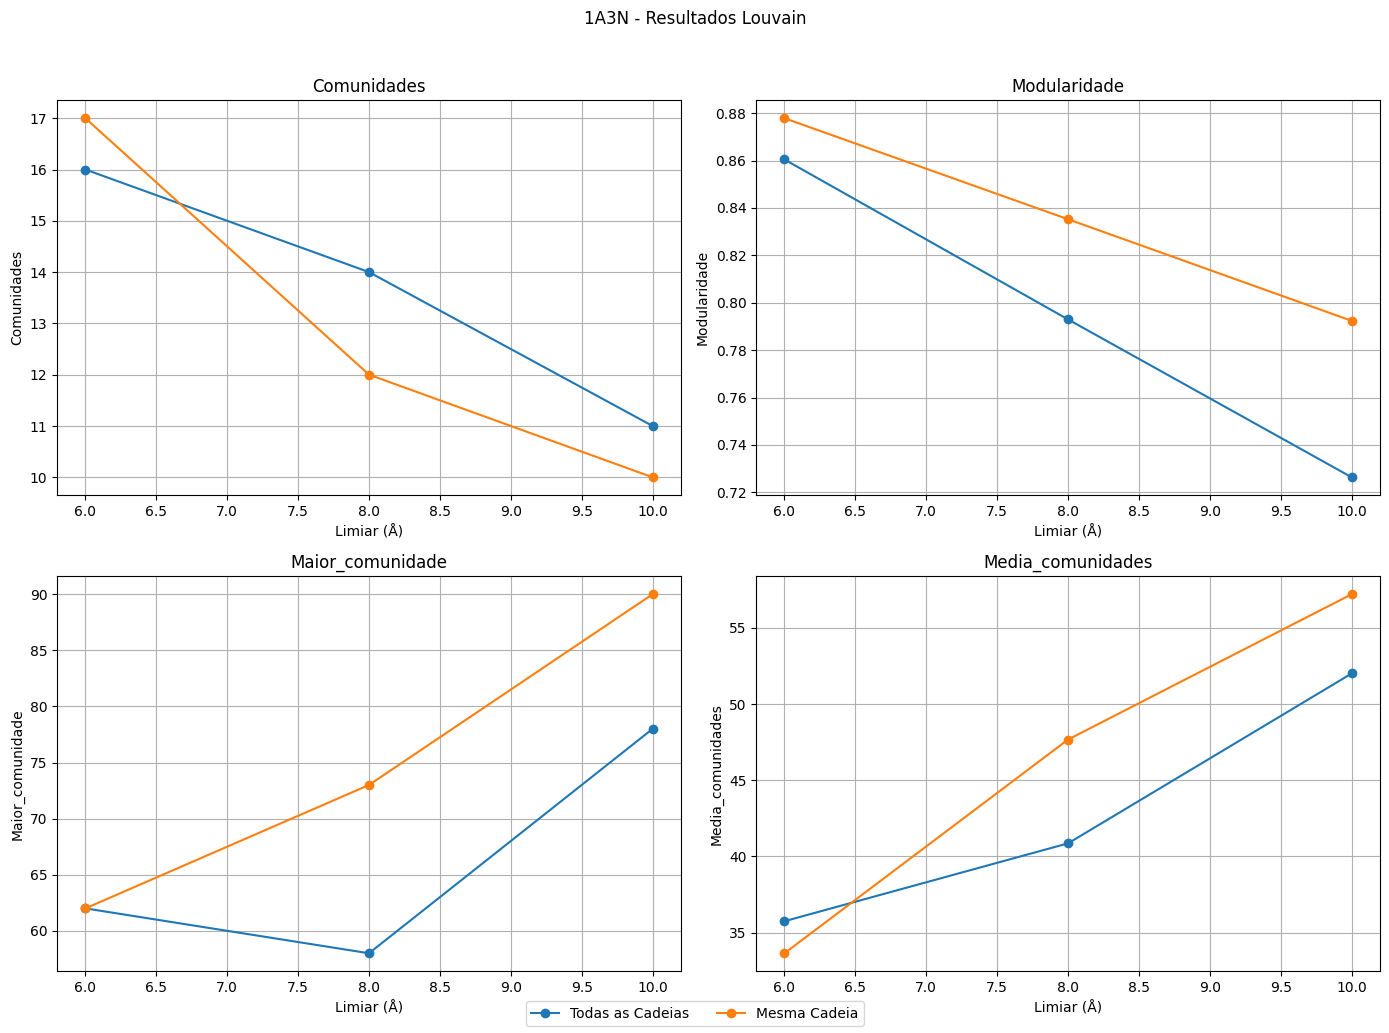

In [9]:
# Métricas que queremos visualizar
metricas = ["comunidades", "modularidade", "maior_comunidade", "media_comunidades"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, metrica in enumerate(metricas):
    ax = axes[i]
    
    for modelo in df_louvain["modelo"].unique():
        dados = df_louvain[df_louvain["modelo"] == modelo]
        
        ax.plot(
            dados["limiar"],
            dados[metrica],
            marker="o",
            label=modelo
        )
    
    ax.set_title(metrica.capitalize())
    ax.set_xlabel("Limiar (Å)")
    ax.set_ylabel(metrica.capitalize())
    ax.grid(True)

# Legenda única para todos os subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels))

plt.suptitle(nome_proteina+" - Resultados Louvain", y=1.02)
plt.tight_layout()
plt.show()
